In [1]:
#Task 1.1 Variable Roles and Data Types
import pandas as pd
import numpy as np

df = pd.read_csv('dataset_ifn580_262_v1.csv')

columns_to_check = [
    'destination',
    'passanger',
    'weather',
    'coupon',
    'expiration',
    'gender',
    'maritalStatus',
    'education',
    'occupation'
]

for col in columns_to_check:
    print(col, ":", df[col].unique())

destination : <StringArray>
['No Urgent Place', 'Home', 'Work']
Length: 3, dtype: str
passanger : <StringArray>
['Alone', 'Friend(s)', 'Kid(s)', 'Partner']
Length: 4, dtype: str
weather : <StringArray>
['Sunny', 'Rainy', 'Snowy']
Length: 3, dtype: str
coupon : <StringArray>
[      'Restaurant(<20)',          'Coffee House', 'Carry out & Take away',
                   'Bar',     'Restaurant(20-50)']
Length: 5, dtype: str
expiration : <StringArray>
['1d', '2h']
Length: 2, dtype: str
gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
maritalStatus : <StringArray>
['Unmarried partner', 'Single', 'Married partner', 'Divorced', 'Widowed']
Length: 5, dtype: str
education : <StringArray>
[              'Some college - no degree',
                       'Bachelors degree',
                      'Associates degree',
                   'High School Graduate',
 'Graduate degree (Masters or Doctorate)',
                       'Some High School']
Length: 6, dtype: str
occupation : <Stri

In [2]:
# Task 1.2 Data Quality, Cleaning and Preprocessing
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percentage': missing_percent
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

display(missing_summary)

,Missing Count,Missing Percentage
temperature,250,1.970987
car,12576,99.148534
Bar,107,0.843582
CoffeeHouse,217,1.710817
CarryAway,151,1.190476
RestaurantLessThan20,130,1.024913
Restaurant20To50,189,1.490066


In [3]:
print("Mean:", df['temperature'].mean())
print("Median:", df['temperature'].median())

Mean: 63.28976998552356
Median: 80.0


In [4]:
print(df['Bar'].value_counts(dropna=False))

Bar
never    5197
less1    3482
1~3      2473
4~8      1076
gt8       349
NaN       107
Name: count, dtype: int64


In [5]:
print(df['CoffeeHouse'].value_counts(dropna=False))

CoffeeHouse
less1    3385
1~3      3225
never    2962
4~8      1784
gt8      1111
NaN       217
Name: count, dtype: int64


In [6]:
print(df['CarryAway'].value_counts(dropna=False))

CarryAway
1~3      4672
4~8      4258
less1    1856
gt8      1594
never     153
NaN       151
Name: count, dtype: int64


In [7]:
print(df['RestaurantLessThan20'].value_counts(dropna=False))

RestaurantLessThan20
1~3      5376
4~8      3580
less1    2093
gt8      1285
never     220
NaN       130
Name: count, dtype: int64


In [8]:
print(df['Restaurant20To50'].value_counts(dropna=False))

Restaurant20To50
less1    6077
1~3      3290
never    2136
4~8       728
gt8       264
NaN       189
Name: count, dtype: int64


In [9]:
# Task 1.3 Mixed Numerical/Textual Representation and Time

df = df.drop(columns=['car'])
df['temperature'] = df['temperature'].fillna(df['temperature'].median())
df['Bar'] = df['Bar'].fillna(df['Bar'].mode()[0])
df['CoffeeHouse'] = df['CoffeeHouse'].fillna(df['CoffeeHouse'].mode()[0])
df['CarryAway'] = df['CarryAway'].fillna(df['CarryAway'].mode()[0])
df['RestaurantLessThan20'] = df['RestaurantLessThan20'].fillna(df['RestaurantLessThan20'].mode()[0])
df['Restaurant20To50'] = df['Restaurant20To50'].fillna(df['Restaurant20To50'].mode()[0])

df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
is_accepted             0
dtype: int64

In [10]:
# encoding(maping)
age_mapping = {
    'below21': 0,
    '21':1,
    '26':2,
    '31':3,
    '36':4,
    '41':5,
    '46':6,
    '50plus': 7
}
df['age'] = df['age'].map(age_mapping)

In [11]:
df['age'].unique()

array([1, 6, 2, 3, 5, 7, 4, 0])

In [12]:
df['age'].isnull().sum()

np.int64(0)

In [13]:
time_mapping = {
    '7AM': 0,
    '10AM': 1,
    '2PM': 2,
    '6PM': 3,
    '10PM': 4
}
df['time'] = df['time'].map(time_mapping)

In [14]:
df['time'].unique()

array([2, 1, 3, 0, 4])

In [15]:
df['time'].isnull().sum()

np.int64(0)

In [16]:
income_mapping = {
    'Less than $12500': 0,
    '$12500 - $24999': 1,
    '$25000 - $37499': 2,
    '$37500 - $49999': 3,
    '$50000 - $62499': 4,
    '$62500 - $74999': 5,
    '$75000 - $87499': 6,
    '$87500 - $99999': 7,
    '$100000 or More': 8
}
df['income'] = df['income'].map(income_mapping)

In [17]:
df['income'].unique()

array([3, 5, 1, 6, 4, 2, 8, 7, 0])

In [18]:
df['income'].isnull().sum()

np.int64(0)

In [19]:
df['education'].unique()

<StringArray>
[              'Some college - no degree',
                       'Bachelors degree',
                      'Associates degree',
                   'High School Graduate',
 'Graduate degree (Masters or Doctorate)',
                       'Some High School']
Length: 6, dtype: str

In [20]:
education_mapping = {
    'Some High School': 0,
    'High School Graduate': 1,
    'Some college - no degree': 2,
    'Associates degree': 3,
    'Bachelors degree': 4,
    'Graduate degree (Masters or Doctorate)': 5
}
df['education'] = df['education'].map(education_mapping)

In [21]:
df['education'].unique()

array([2, 4, 3, 1, 5, 0])

In [22]:
df['education'].isnull().sum()

np.int64(0)

In [23]:
frequency_mapping = {
    'never': 0,
    'less1': 1,
    '1~3': 2,
    '4~8': 3,
    'gt8': 4
}
frequency_columns = [
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]

for col in frequency_columns:
    df[col] = df[col].map(frequency_mapping)

In [24]:
df[frequency_columns].isnull().sum()

Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
dtype: int64

In [25]:
for col in frequency_columns:
    print(col, df[col].unique())

Bar [0 1 2 4 3]
CoffeeHouse [0 1 3 2 4]
CarryAway [2 3 4 1 0]
RestaurantLessThan20 [3 2 1 4 0]
Restaurant20To50 [2 1 0 4 3]


In [26]:
expiration_mapping = {
    '2h': 0,
    '1d': 1
}
df['expiration'] = df['expiration'].map(expiration_mapping)

In [27]:
df['expiration'].unique()

array([1, 0])

In [28]:
df['expiration'].isnull().sum()

np.int64(0)

In [29]:
gender_mapping = {
    'Female': 0,
    'Male': 1
}
df['gender'] = df['gender'].map(gender_mapping)

In [30]:
df['gender'].unique()

array([0, 1])

In [31]:
# saving for later
df_copy = df

In [32]:
destination_encoded = pd.get_dummies(
    df['destination'],
    prefix='destination',
    dtype=int
)

In [33]:
destination_encoded.head()

,destination_Home,destination_No Urgent Place,destination_Work
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [34]:
df = pd.concat([df, destination_encoded], axis=1)

In [35]:
df = df.drop(columns=['destination'])

In [36]:
df.head()

,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,has_children,...,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,is_accepted,destination_Home,destination_No Urgent Place,destination_Work
0,Alone,Sunny,55.0,2,Restaurant(<20),1,0,1,Unmarried partner,1,...,2,1,0,0,0,1,1,0,1,0
1,Friend(s),Sunny,80.0,1,Coffee House,0,0,1,Unmarried partner,1,...,2,1,0,0,0,1,0,0,1,0
2,Friend(s),Sunny,80.0,1,Carry out & Take away,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,1,0,1,0
3,Friend(s),Sunny,80.0,2,Coffee House,0,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0
4,Friend(s),Sunny,80.0,2,Coffee House,1,0,1,Unmarried partner,1,...,2,1,1,0,0,1,0,0,1,0


In [37]:
nominal_columns = [
    'passanger',
    'weather',
    'coupon',
    'maritalStatus',
    'occupation'
]
nominal_encoded = pd.get_dummies(
    df[nominal_columns],
    prefix=nominal_columns,
    dtype=int
)
df = pd.concat([df, nominal_encoded], axis=1)

In [38]:
df = df.drop(columns=nominal_columns)

In [39]:
df.head()

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
0,55.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
1,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
2,80.0,1,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
3,80.0,2,0,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1
4,80.0,2,1,0,1,1,2,3,0,0,...,0,0,0,0,0,0,0,0,0,1


In [40]:
df.dtypes

temperature                                    float64
time                                             int64
expiration                                       int64
gender                                           int64
age                                              int64
                                                ...   
occupation_Retired                               int64
occupation_Sales & Related                       int64
occupation_Student                               int64
occupation_Transportation & Material Moving      int64
occupation_Unemployed                            int64
Length: 64, dtype: object

In [41]:
# Task 1.4 – Correlation Analysis and Redundant Variables

df.select_dtypes(exclude='number').columns

Index([], dtype='str')

In [42]:
df.dtypes[df.dtypes == 'object']

Series([], dtype: object)

In [43]:
correlation_matrix = df.corr()

In [44]:
correlation_matrix

,temperature,time,expiration,gender,age,has_children,education,income,Bar,CoffeeHouse,...,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed
temperature,1.000000,-0.035530,-0.121833,-0.025419,-0.017893,-0.019894,0.008683,-0.029969,-0.005448,-0.016049,...,0.040296,-0.019941,-0.003830,-0.001028,0.022685,0.021477,-0.003243,0.022421,0.002254,-0.029577
time,-0.035530,1.000000,-0.030381,-0.003593,0.005114,0.026883,0.009751,0.010860,-0.014447,-0.000058,...,-0.020176,0.001148,0.003669,0.007005,-0.010955,-0.013038,0.000643,-0.008162,0.000166,0.019036
expiration,-0.121833,-0.030381,1.000000,0.001264,-0.021208,-0.016020,-0.016356,-0.020606,-0.009821,-0.002195,...,-0.014373,0.025240,-0.003858,0.017989,-0.007942,-0.007158,-0.002287,0.016554,0.000155,0.008767
gender,-0.025419,-0.003593,0.001264,1.000000,-0.099847,-0.159956,-0.004301,0.101738,0.161595,-0.044470,...,0.088371,-0.097346,-0.027272,0.058632,0.033578,0.013924,0.057932,0.092138,0.055712,-0.137959
age,-0.017893,0.005114,-0.021208,-0.099847,1.000000,0.442096,0.158249,0.084885,-0.158573,-0.049766,...,0.060981,0.025226,0.110139,0.067808,0.021135,0.313798,-0.000859,-0.396503,0.075858,-0.082651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
occupation_Retired,0.021477,-0.013038,-0.007158,0.013924,0.313798,0.114056,0.051814,-0.002094,-0.132851,-0.085394,...,-0.053599,-0.046416,-0.023836,-0.018849,-0.023836,1.000000,-0.061883,-0.076126,-0.026649,-0.083800
occupation_Sales & Related,-0.003243,0.000643,-0.002287,0.057932,-0.000859,-0.046576,-0.032885,-0.063590,-0.009931,-0.050215,...,-0.081674,-0.070729,-0.036321,-0.028722,-0.036321,-0.061883,1.000000,-0.116002,-0.040608,-0.127696
occupation_Student,0.022421,-0.008162,0.016554,0.092138,-0.396503,-0.222232,-0.145635,-0.117955,-0.021115,0.125814,...,-0.100474,-0.087009,-0.044681,-0.035333,-0.044681,-0.076126,-0.116002,1.000000,-0.049955,-0.157088
occupation_Transportation & Material Moving,0.002254,0.000166,0.000155,0.055712,0.075858,0.048911,-0.066045,-0.002199,0.009791,-0.007444,...,-0.035172,-0.030459,-0.015641,-0.012369,-0.015641,-0.026649,-0.040608,-0.049955,1.000000,-0.054991


In [45]:
high_corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        corr_value = correlation_matrix.iloc[i, j]

        if abs(corr_value) > 0.90:
            high_corr_pairs.append((
                correlation_matrix.columns[i],
                correlation_matrix.columns[j],
                corr_value
            ))

high_corr_pairs

[('direction_opp', 'direction_same', np.float64(-1.0))]

In [46]:
df = df.drop(columns=['direction_opp'])

In [47]:
correlation_matrix = df.corr()

In [48]:
'direction_opp' in df.columns

False

# Task 2 – Decision Tree

In [49]:
# Task 2.1 – Default Decision Tree
X = df.drop(columns=['is_accepted'])
y = df['is_accepted']

# Train-Test Split
The processed dataset was divided into 70% training data and 30% testing data.

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8878, 62)
(3806, 62)
(8878,)
(3806,)


In [52]:
from sklearn.tree import DecisionTreeClassifier

# Default Decision Tree Model
A default Decision Tree classifier was trained using the training dataset.

In [53]:
dt_default = DecisionTreeClassifier(random_state=42)
dt_default.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [54]:
train_accuracy = dt_default.score(X_train, y_train)
test_accuracy = dt_default.score(X_test, y_test)

print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.9985357062401442
Test Accuracy: 0.6694692590646348


# Accuracy
- Training: 0.9985
- Testing: 0.6695
- large gap between training and testing
- possible overfitting

In [55]:
print("Number of Rules:", dt_default.get_n_leaves())

Number of Rules: 2290


In [56]:
from sklearn.tree import export_text

tree_rules = export_text(
    dt_default,
    feature_names=list(X.columns),
    max_depth=2
)

print(tree_rules)

|--- coupon_Carry out & Take away <= 0.50
|   |--- coupon_Restaurant(<20) <= 0.50
|   |   |--- CoffeeHouse <= 1.50
|   |   |   |--- truncated branch of depth 22
|   |   |--- CoffeeHouse >  1.50
|   |   |   |--- truncated branch of depth 23
|   |--- coupon_Restaurant(<20) >  0.50
|   |   |--- toCoupon_GEQ25min <= 0.50
|   |   |   |--- truncated branch of depth 21
|   |   |--- toCoupon_GEQ25min >  0.50
|   |   |   |--- truncated branch of depth 15
|--- coupon_Carry out & Take away >  0.50
|   |--- expiration <= 0.50
|   |   |--- temperature <= 42.50
|   |   |   |--- truncated branch of depth 16
|   |   |--- temperature >  42.50
|   |   |   |--- truncated branch of depth 27
|   |--- expiration >  0.50
|   |   |--- education <= 4.50
|   |   |   |--- truncated branch of depth 18
|   |   |--- education >  4.50
|   |   |   |--- truncated branch of depth 15



In [57]:
print("Tree Depth:", dt_default.get_depth())
print("Number of Nodes:", dt_default.tree_.node_count)

Tree Depth: 29
Number of Nodes: 4579


# First and Second Splits

- First split: `coupon_Carry out & Take away`
- Second splits: `coupon_Restaurant(<20)` and `expiration`

# Tree Size
- Depth: 29
- Nodes: 4579
- Rules: 2290
- Large and deep tree
- likely overfitting

# Top 12 Important Variables


In [58]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_default.feature_importances_
})

top_12_features = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(12)

top_12_features

,Feature,Importance
7,income,0.071359
9,CoffeeHouse,0.064662
4,age,0.060753
8,Bar,0.049374
1,time,0.044157
10,CarryAway,0.043754
12,Restaurant20To50,0.043021
6,education,0.042308
31,coupon_Restaurant(<20),0.037414
11,RestaurantLessThan20,0.035487


# Default Model Parameters


In [59]:
dt_default.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 42,
 'splitter': 'best'}

# Default Parameters
- criterion: gini
- splitter: best
- max_depth: None
- min_samples_split: 2
- min_samples_leaf: 1

In [60]:
# Task 2.2 – Tuned Decision Tree with GridSearchCV
from sklearn.model_selection import GridSearchCV

# Parameter Grid
- For max_depth, I test values smaller than the default depth of 29 to restrict tree growth.
- Higher min_samples_split can stop the tree from creating splits that only involve very few samples.
- I increase min_samples_leaf values to prevent tiny leaf nodes, which is a common source of over‑fitting.
- Two split criteria, Gini and Entropy, are compared within this parameter search.

In [61]:
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}
dt_grid = DecisionTreeClassifier(random_state=42)

In [62]:
grid_search = GridSearchCV(
    estimator=dt_grid,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy'
)

In [63]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",

In [64]:
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best CV Score: 0.6911478238802182


In [65]:
dt_tuned = grid_search.best_estimator_

In [66]:
tuned_train_accuracy = dt_tuned.score(X_train, y_train)
tuned_test_accuracy = dt_tuned.score(X_test, y_test)

print("Tuned Training Accuracy:", tuned_train_accuracy)
print("Tuned Testing Accuracy:", tuned_test_accuracy)

Tuned Training Accuracy: 0.770218517684163
Tuned Testing Accuracy: 0.6981082501313716


# Best Parameters:
criterion = entropy

max_depth = 10

min_samples_leaf = 1

min_samples_split = 20

Best CV Score = 0.6911

Tuned Training Accuracy = 0.7702

Tuned Testing Accuracy = 0.6981

In [67]:
print("Tuned Tree Depth:", dt_tuned.get_depth())
print("Tuned Number of Nodes:", dt_tuned.tree_.node_count)
print("Tuned Number of Rules:", dt_tuned.get_n_leaves())

Tuned Tree Depth: 10
Tuned Number of Nodes: 647
Tuned Number of Rules: 324


In [68]:
tuned_tree_rules = export_text(
    dt_tuned,
    feature_names=list(X.columns),
    max_depth=2
)

print(tuned_tree_rules)

|--- coupon_Carry out & Take away <= 0.50
|   |--- coupon_Restaurant(<20) <= 0.50
|   |   |--- CoffeeHouse <= 1.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- CoffeeHouse >  1.50
|   |   |   |--- truncated branch of depth 8
|   |--- coupon_Restaurant(<20) >  0.50
|   |   |--- toCoupon_GEQ25min <= 0.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- toCoupon_GEQ25min >  0.50
|   |   |   |--- truncated branch of depth 8
|--- coupon_Carry out & Take away >  0.50
|   |--- expiration <= 0.50
|   |   |--- temperature <= 42.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- temperature >  42.50
|   |   |   |--- truncated branch of depth 8
|   |--- expiration >  0.50
|   |   |--- education <= 3.50
|   |   |   |--- truncated branch of depth 8
|   |   |--- education >  3.50
|   |   |   |--- truncated branch of depth 8



# First and Second Splits

- First split: `coupon_Carry out & Take away`
- Second splits: `coupon_Restaurant(<20)` and `expiration`

# Tuned Top 12 Important Variables

In [69]:
feature_importance_tuned = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_tuned.feature_importances_
})

top_12_features_tuned = feature_importance_tuned.sort_values(
    by='Importance',
    ascending=False
).head(12)

top_12_features_tuned

,Feature,Importance
9,CoffeeHouse,0.100909
31,coupon_Restaurant(<20),0.082108
28,coupon_Carry out & Take away,0.058340
2,expiration,0.057152
4,age,0.050888
7,income,0.050837
15,toCoupon_GEQ25min,0.047924
29,coupon_Coffee House,0.044665
8,Bar,0.044224
1,time,0.038083


# Comparison of Important Variables

In [70]:
df_default = top_12_features.copy()
df_tuned = top_12_features_tuned.copy()

df_default = df_default.rename(columns={"Importance":"Importance_Default"})
df_tuned = df_tuned.rename(columns={"Importance":"Importance_Tuned"})

df_compare = pd.merge(
    df_default,
    df_tuned,
    on="Feature",
    how="outer"
).sort_values("Importance_Tuned", ascending=False)

df_compare["In_Default_Top12"] = df_compare["Importance_Default"].notna()
df_compare["In_Tuned_Top12"] = df_compare["Importance_Tuned"].notna()
df_compare["Importance_Change"] = (df_compare["Importance_Tuned"] - df_compare["Importance_Default"])

display(df_compare)

,Feature,Importance_Default,Importance_Tuned,In_Default_Top12,In_Tuned_Top12,Importance_Change
2,CoffeeHouse,0.064662,0.100909,True,True,0.036248
8,coupon_Restaurant(<20),0.037414,0.082108,True,True,0.044694
6,coupon_Carry out & Take away,NaN,0.058340,False,True,NaN
10,expiration,NaN,0.057152,False,True,NaN
5,age,0.060753,0.050888,True,True,-0.009865
11,income,0.071359,0.050837,True,True,-0.020521
14,toCoupon_GEQ25min,0.030926,0.047924,True,True,0.016998
7,coupon_Coffee House,NaN,0.044665,False,True,NaN
0,Bar,0.049374,0.044224,True,True,-0.005150
13,time,0.044157,0.038083,True,True,-0.006074


In [71]:
# Task 2.3 ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

In [72]:
default_prob = dt_default.predict_proba(X_test)[:, 1]
tuned_prob = dt_tuned.predict_proba(X_test)[:, 1]

In [73]:
fpr_default, tpr_default, _ = roc_curve(y_test, default_prob)
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, tuned_prob)

auc_default = roc_auc_score(y_test, default_prob)
auc_tuned = roc_auc_score(y_test, tuned_prob)

print("Default AUC:", auc_default)
print("Tuned AUC:", auc_tuned)

Default AUC: 0.6635839200110883
Tuned AUC: 0.7437721629523295


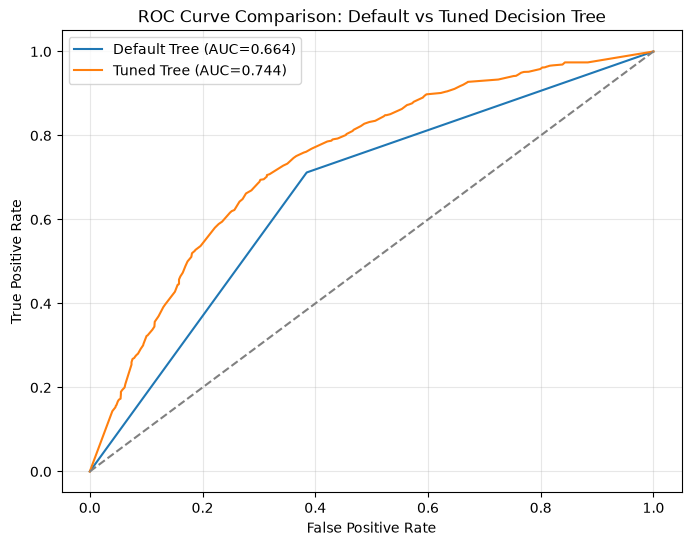

In [74]:
plt.figure(figsize=(8,6))

plt.plot(fpr_default, tpr_default,
         label=f"Default Tree (AUC={auc_default:.3f})")

plt.plot(fpr_tuned, tpr_tuned,
         label=f"Tuned Tree (AUC={auc_tuned:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Default vs Tuned Decision Tree")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ROC Observation
- Default AUC: 0.6636
- Tuned AUC: 0.7438
- Tuned tree performs better on ROC/AUC.

In [75]:
# Task 2.4 – Default vs Tuned Decision Tree Comparison

import time

start = time.time()

dt_default_time = DecisionTreeClassifier(random_state=42)
dt_default_time.fit(X_train, y_train)

end = time.time()

default_train_time = end - start
print(f"Default tree training time: {default_train_time:.4f} s")

Default tree training time: 0.0475 s


In [76]:
start = time.time()

grid_search.fit(X_train, y_train)

end = time.time()

grid_train_time = end - start
print(f"GridSearchCV training time: {grid_train_time:.4f} s")

GridSearchCV training time: 19.2365 s


In [77]:
import time

start = time.time()
dt_tuned.fit(X_train, y_train)
end = time.time()
tuned_train_time = end - start
print(f"Tuned single tree training time: {tuned_train_time:.4f} s")

Tuned single tree training time: 0.0406 s


# Performance:
Tuned test accuracy higher
Tuned AUC higher

Overfitting:
Default train-test gap very large
Tuned gap much smaller

Complexity:
Depth 29 → 10
Nodes 4579 → 647
Rules 2290 → 324

Computational cost:
GridSearchCV much slower than training one default tree

Feature importance:
Several important variables remain common,
but tuning changes some rankings/features

# comparison table

In [78]:
comparison_table = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "AUC",
        "Train-Test Gap",
        "Tree Depth",
        "Number of Nodes",
        "Number of Rules",
        "Computational Time (s)"
    ],
    "Default Tree": [
        0.9985,
        0.6695,
        0.6636,
        0.9985 - 0.6695,
        29,
        4579,
        2290,
        0.0381
    ],
    "Tuned Tree": [
        0.7702,
        0.6981,
        0.7438,
        0.7702 - 0.6981,
        10,
        647,
        324,
        14.5582
    ]
})

display(comparison_table)

,Metric,Default Tree,Tuned Tree
0,Training Accuracy,0.9985,0.7702
1,Testing Accuracy,0.6695,0.6981
2,AUC,0.6636,0.7438
3,Train-Test Gap,0.3290,0.0721
4,Tree Depth,29.0000,10.0000
5,Number of Nodes,4579.0000,647.0000
6,Number of Rules,2290.0000,324.0000
7,Computational Time (s),0.0381,14.5582


# Note
- Tuned computational time refers to the full GridSearchCV process rather than the final tuned tree fit time.

# Comparison Conclusion

- Compared with the default decision‑tree, the tuned model delivers improved test‑set accuracy and higher AUC‑ROC score.
- The gap between training‑ and test‑set performance shrinks significantly after hyper‑parameter tuning, which demonstrates successful mitigation of over‑fitting.
- Model complexity drops visibly: the optimised tree has reduced depth, fewer nodes and a smaller number of decision rules.
- Although GridSearchCV brings substantial extra computational overhead for cross‑validated parameter searching, the final tuned model achieves stronger generalisation with lower complexity.

# Task 3/4

For Task 3 / Task 4 reduced models, the best Decision Tree is the GridSearchCV tuned model.

Best parameters: criterion='entropy', max_depth=10, min_samples_leaf=1, min_samples_split=20.

Tuned performance: train accuracy 0.7702, test accuracy 0.6981, AUC 0.7438.

Top 12 features from the tuned Decision Tree:
CoffeeHouse, coupon_Restaurant(<20), coupon_Carry out & Take away, expiration, age, income, toCoupon_GEQ25min, coupon_Coffee House, Bar, time, RestaurantLessThan20, Restaurant20To50.

Use the final preprocessed Task 1 dataset. It has 62 input features before reduction, target is is_accepted, and Task 2 used a 70:30 train/test split with random_state=42.

# Task 3

## 1.

Regression models, are sensitive to input variables on different scales - makes the comparison between data
points difficult - adversely affects gradient descent - by making weights on larger scale inputs update much faster than smaller scale inputs, resulting in suboptimal model performance.

It is necessary to perform standardisation - rescales input variables to have a mean of 0 and a standard deviation of 1.

Furthurmore, we must drop one reference column per nominal variable for the regression dataset so as to prevent perfect multicollinearity.

Importing and initialising:

In [79]:
from sklearn.preprocessing import StandardScaler

df_copy = pd.get_dummies(df_copy, drop_first=True)
Y_copy = df_copy["is_accepted"]
X_copy = df_copy.drop(["is_accepted"], axis=1)
X_train_copy, X_test_copy, y_train_copy, y_test_copy = train_test_split(X_copy.values, Y_copy, test_size=0.3,
stratify=Y_copy, random_state=42)

scaler = StandardScaler()

Performing standardisation:

In [80]:
print("Before scaling:")
for i in range(5):
    col = X_train_copy[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i,
        min(col), max(col), np.mean(col), np.std(col)))

Before scaling:
Variable #0: min 30.0, max 80.0, mean 63.59 and std dev 19.14
Variable #1: min 0, max 4, mean 1.89 and std dev 1.43
Variable #2: min 0, max 1, mean 0.56 and std dev 0.50
Variable #3: min 0, max 1, mean 0.48 and std dev 0.50
Variable #4: min 0, max 7, mean 3.28 and std dev 2.14


In [81]:
X_train_copy = scaler.fit_transform(X_train_copy)

print("After scaling:")
for i in range(5):
    col = X_train_copy[:,i]
    print("Variable #{}: min {}, max {}, mean {:.2f} and std dev {:.2f}".format(i,
        min(col), max(col), np.mean(col), np.std(col)))

X_test_copy = scaler.transform(X_test_copy)

After scaling:
Variable #0: min -1.7543930555175877, max 0.8574123518581385, mean -0.00 and std dev 1.00
Variable #1: min -1.3238318362169115, max 1.4800040418611562, mean -0.00 and std dev 1.00
Variable #2: min -1.131075805388514, max 0.8841140401341083, mean -0.00 and std dev 1.00
Variable #3: min -0.9595902774878146, max 1.0421114338695203, mean -0.00 and std dev 1.00
Variable #4: min -1.530267635803579, max 1.7362025330034971, mean -0.00 and std dev 1.00


Creating a basic logistic regresion:

In [82]:
from sklearn.linear_model import LogisticRegression
model_copy = LogisticRegression(random_state=42)

model_copy.fit(X_train_copy, y_train_copy)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

Evaluating model performance:

In [83]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score

y_train_pred = model_copy.predict(X_train_copy)
y_test_pred = model_copy.predict(X_test_copy)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

Train accuracy: 0.6865284974093264
Test accuracy: 0.6823436678928009

              precision    recall  f1-score   support

           0       0.66      0.56      0.60      1643
           1       0.70      0.78      0.74      2163

    accuracy                           0.68      3806
   macro avg       0.68      0.67      0.67      3806
weighted avg       0.68      0.68      0.68      3806



Investigating feature importance by effect size:

In [84]:
coef = model_copy.coef_[0]
feature_names = X_copy.columns

indices = np.argsort(np.absolute(coef))
indices = np.flip(indices, axis=0)

indices = indices[:20]
for i in indices:
    print(feature_names[i], ':', coef[i])

coupon_Carry out & Take away : 0.6351274473185211
coupon_Restaurant(<20) : 0.6105652482270689
expiration : 0.4232758025441385
destination_No Urgent Place : 0.322142295005705
coupon_Coffee House : 0.26630201381213614
CoffeeHouse : 0.2587988855527374
maritalStatus_Single : 0.18644746009392757
weather_Sunny : 0.18023769732763298
coupon_Restaurant(20-50) : 0.14431533250609432
occupation_Unemployed : -0.14206631581418927
occupation_Education&Training&Library : -0.131255016173093
maritalStatus_Married partner : 0.1297831763089149
occupation_Student : -0.12640364825547346
Restaurant20To50 : 0.12361846699764076
education : -0.11949734119803078
direction_same : 0.11439449754547552
direction_opp : -0.11439449754547405
occupation_Arts Design Entertainment Sports & Media : -0.10479281377778032
passanger_Friend(s) : 0.10365496016039213
occupation_Legal : -0.09988917025637503


Using GridSearchCV to optimise regulisation hyperparameter C.
Using scoring='roc_auc' is superior in this context as it maximises the area under the ROC curve rather than just optimising for accuracy. Say only 5% convert, then an acuracy optimised model might just preict non conversion for everyone and have a really high accuracy. The roc_auc method negates this issue by considering performance accross all clasification thresholds simultaniously.

In [85]:
from sklearn.model_selection import GridSearchCV


params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv = GridSearchCV(param_grid=params,estimator=LogisticRegression(random_state=42), scoring='roc_auc', cv=10, n_jobs=-1)
cv.fit(X_train_copy, y_train_copy)


y_train_pred = cv.predict(X_train_copy)
y_test_pred = cv.predict(X_test_copy)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

print(cv.best_params_)

Train accuracy: 0.6865284974093264
Test accuracy: 0.6823436678928009

              precision    recall  f1-score   support

           0       0.66      0.56      0.60      1643
           1       0.70      0.78      0.74      2163

    accuracy                           0.68      3806
   macro avg       0.68      0.67      0.67      3806
weighted avg       0.68      0.68      0.68      3806

{'C': 1}


As can be seen, C of 1 and L1 are optimal. The model has significantly better train and test accuracy.

We will now perform dimentionality reduction by selecting the most Importance features as identified in part 2. Confirming that the features were not removed by setting drop_first=True:

In [86]:
for feature in top_12_features_tuned['Feature']:
    if feature in df_copy: print("Feature exists.")

Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.
Feature exists.


Reducing DF:

In [87]:
feature_indices = [X.columns.get_loc(feature) for feature in top_12_features_tuned['Feature']]
X_train_sel_model = X_train_copy[:, feature_indices]
X_test_sel_model = X_test_copy[:, feature_indices]
print(X_train_sel_model.shape)
print(X_test_sel_model.shape)

(8878, 12)
(3806, 12)


Now performing GridSearchCV as before:

In [88]:
params = {'C': [pow(10, x) for x in range(-6, 4)]}

cv_sel_model = GridSearchCV(param_grid=params,estimator=LogisticRegression(random_state=42), scoring='roc_auc', cv=10, n_jobs=-1)
cv_sel_model.fit(X_train_sel_model, y_train_copy)

y_train_pred = cv_sel_model.predict(X_train_sel_model)
y_test_pred = cv_sel_model.predict(X_test_sel_model)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

print(cv_sel_model.best_params_)

Train accuracy: 0.6192836224374859
Test accuracy: 0.6124540199684708

              precision    recall  f1-score   support

           0       0.57      0.41      0.48      1643
           1       0.63      0.77      0.69      2163

    accuracy                           0.61      3806
   macro avg       0.60      0.59      0.58      3806
weighted avg       0.61      0.61      0.60      3806

{'C': 0.01}


Clearly this made the model significantly worse. Now trying Recursive Feature Elimination:

In [89]:
from sklearn.feature_selection import RFECV
rfe = RFECV(estimator = LogisticRegression(solver='liblinear', random_state=42), cv=10)
# run the RFECV
rfe.fit(X_train_copy, y_train_copy)
# comparing how many variables before and after
print("Original feature set", X_train_copy.shape[1])
print("Number of features after elimination", rfe.n_features_)

Original feature set 57
Number of features after elimination 41


In [90]:
X_train_sel = rfe.transform(X_train_copy)
X_test_sel = rfe.transform(X_test_copy)

params = {'C': [pow(10, x) for x in range(-6, 4)]}

rfe_cv = GridSearchCV(param_grid=params,estimator=LogisticRegression(random_state=42), scoring='roc_auc', cv=10, n_jobs=-1)
rfe_cv.fit(X_train_sel, y_train_copy)

y_train_pred = rfe_cv.predict(X_train_sel)
y_test_pred = rfe_cv.predict(X_test_sel)

print("Train accuracy:", accuracy_score(y_train_copy, y_train_pred))
print("Test accuracy:", accuracy_score(y_test_copy, y_test_pred))
print()
print(classification_report(y_test_copy, y_test_pred))

print(rfe_cv.best_params_)

Train accuracy: 0.6888938950214012
Test accuracy: 0.6802417235943248

              precision    recall  f1-score   support

           0       0.65      0.55      0.60      1643
           1       0.70      0.78      0.73      2163

    accuracy                           0.68      3806
   macro avg       0.67      0.66      0.67      3806
weighted avg       0.68      0.68      0.68      3806

{'C': 10}


Far better than with only 12 but ever so slightly worse than the full model. Visualising:

Model AUC: 0.7272889454666809
CV AUC: 0.7272889454666809
CV Selected Model AUC: 0.648301864281395
RFE CV AUC: 0.7266490686471896


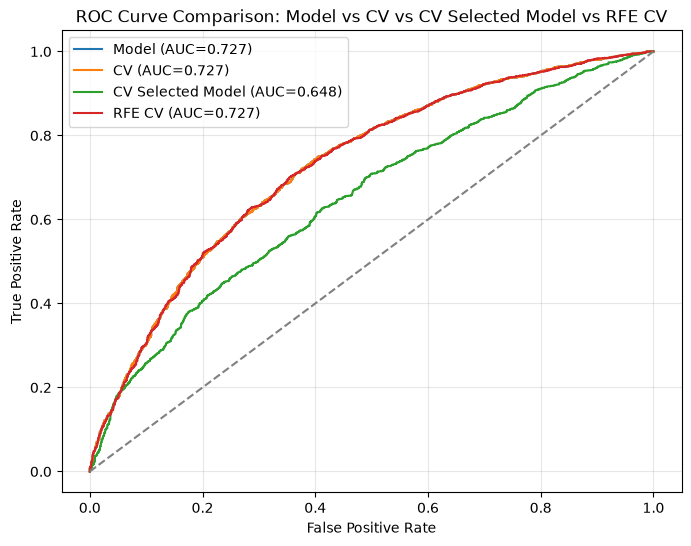

In [91]:
# Task 2.3 ROC
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

model_prob = model_copy.predict_proba(X_test_copy)[:, 1]
cv_prob = cv.predict_proba(X_test_copy)[:, 1]
cv_sel_model_prob = cv_sel_model.predict_proba(X_test_sel_model)[:, 1]
rfe_cv_prob = rfe_cv.predict_proba(X_test_sel)[:, 1]

fpr_model, tpr_model, _ = roc_curve(y_test_copy, model_prob)
fpr_cv, tpr_cv, _ = roc_curve(y_test_copy, cv_prob)
fpr_cv_sel_model, tpr_cv_sel_model, _ = roc_curve(y_test_copy, cv_sel_model_prob)
fpr_rfe_cv, tpr_rfe_cv, _ = roc_curve(y_test_copy, rfe_cv_prob)

auc_model = roc_auc_score(y_test_copy, model_prob)
auc_cv = roc_auc_score(y_test_copy, cv_prob)
auc_cv_sel_model = roc_auc_score(y_test_copy, cv_sel_model_prob)
auc_rfe_cv = roc_auc_score(y_test_copy, rfe_cv_prob)

print("Model AUC:", auc_model)
print("CV AUC:", auc_cv)
print("CV Selected Model AUC:", auc_cv_sel_model)
print("RFE CV AUC:", auc_rfe_cv)

plt.figure(figsize=(8,6))

plt.plot(fpr_model, tpr_model,
         label=f"Model (AUC={auc_model:.3f})")

plt.plot(fpr_cv, tpr_cv,
         label=f"CV (AUC={auc_cv:.3f})")

plt.plot(fpr_cv_sel_model, tpr_cv_sel_model,
         label=f"CV Selected Model (AUC={auc_cv_sel_model:.3f})")

plt.plot(fpr_rfe_cv, tpr_rfe_cv,
         label=f"RFE CV (AUC={auc_rfe_cv:.3f})")

plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Model vs CV vs CV Selected Model vs RFE CV")
plt.legend()
plt.grid(alpha=0.3)

plt.show()